# Name : HIMANI BANSAL AGRAWAL

# Data Science & Machine Learning
# Assignment – Customer Purchase Prediction

# DATA COLLECTION 

In [1]:
import zipfile 
import os 
import pandas as pd 


In [3]:
os.listdir()

['.anaconda',
 '.cache',
 '.conda',
 '.condarc',
 '.continuum',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.keras',
 '.matplotlib',
 '.ms-ad',
 '.nbi',
 '.packettracer',
 '.redhat',
 '.virtual_documents',
 '.vscode',
 '1dimensionalarray.ipynb',
 'anaconda3',
 'AppData',
 'Apple',
 'Application Data',
 'archive (1).zip',
 'bank.zip',
 'c++ coding',
 'c++ coding.txt',
 'Cisco Packet Tracer 6.2sv',
 'Cisco Packet Tracer 8.2.2',
 'CNN.ipynb',
 'coding',
 'Contacts',
 'Cookies',
 'CV.ipynb',
 'DAlab3rd.ipynb',
 'day1.ipynb',
 'day15.ipynb',
 'day17.ipynb',
 'day18.ipynb',
 'day2.ipynb',
 'day3and4.ipynb',
 'day5.ipynb',
 'day6.ipynb',
 'day8.ipynb',
 'day9.ipynb',
 'days10.ipynb',
 'Dear mumma and papa.txt',
 'Decision_tree.ipynb',
 'Desktop',
 'dict.pkl',
 'dictionary.ipynb',
 'Documents',
 'Downloads',
 'Favorites',
 'Happy birthday to my cutie.txt',
 'installation.ipynb',
 'IntelGraphicsProfiles',
 'JOURNAL .txt',
 'KNN.ipynb',
 'lab1.ipynb',
 'Linear Regression',
 'linkedlist1.i

In [9]:
zip_path = "bank.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("bank")

In [11]:
os.listdir("bank")

['bank.csv']

In [13]:
df = pd.read_csv("bank/bank.csv",sep=";")


In [15]:
df.head()

,"age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit"
0,"59,admin.,married,secondary,no,2343,yes,no,unk..."
1,"56,admin.,married,secondary,no,45,no,no,unknow..."
2,"41,technician,married,secondary,no,1270,yes,no..."
3,"55,services,married,secondary,no,2476,yes,no,u..."
4,"54,admin.,married,tertiary,no,184,no,no,unknow..."


In [17]:
df.head(10)

,"age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit"
0,"59,admin.,married,secondary,no,2343,yes,no,unk..."
1,"56,admin.,married,secondary,no,45,no,no,unknow..."
2,"41,technician,married,secondary,no,1270,yes,no..."
3,"55,services,married,secondary,no,2476,yes,no,u..."
4,"54,admin.,married,tertiary,no,184,no,no,unknow..."
5,"42,management,single,tertiary,no,0,yes,yes,unk..."
6,"56,management,married,tertiary,no,830,yes,yes,..."
7,"60,retired,divorced,secondary,no,545,yes,no,un..."
8,"37,technician,married,secondary,no,1,yes,no,un..."
9,"28,services,single,secondary,no,5090,yes,no,un..."


In [19]:
df.shape

(11162, 1)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 1 columns):
 #   Column                                                                                                                      Non-Null Count  Dtype 
---  ------                                                                                                                      --------------  ----- 
 0   age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit  11162 non-null  object
dtypes: object(1)
memory usage: 87.3+ KB


In [25]:
df.describe()

,"age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit"
count,11162
unique,11162
top,"59,admin.,married,secondary,no,2343,yes,no,unk..."
freq,1


# Data Cleaning & Transformation 

In [39]:
# ex- 2.1 Handle Missing / Unknown Values
import pandas as pd 
import numpy as np 


In [41]:
df = pd.read_csv("bank/bank.csv")

In [45]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [47]:

(df == "unknown").sum()

age             0
job            70
marital         0
education     497
default         0
balance         0
housing         0
loan            0
contact      2346
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome     8326
deposit         0
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

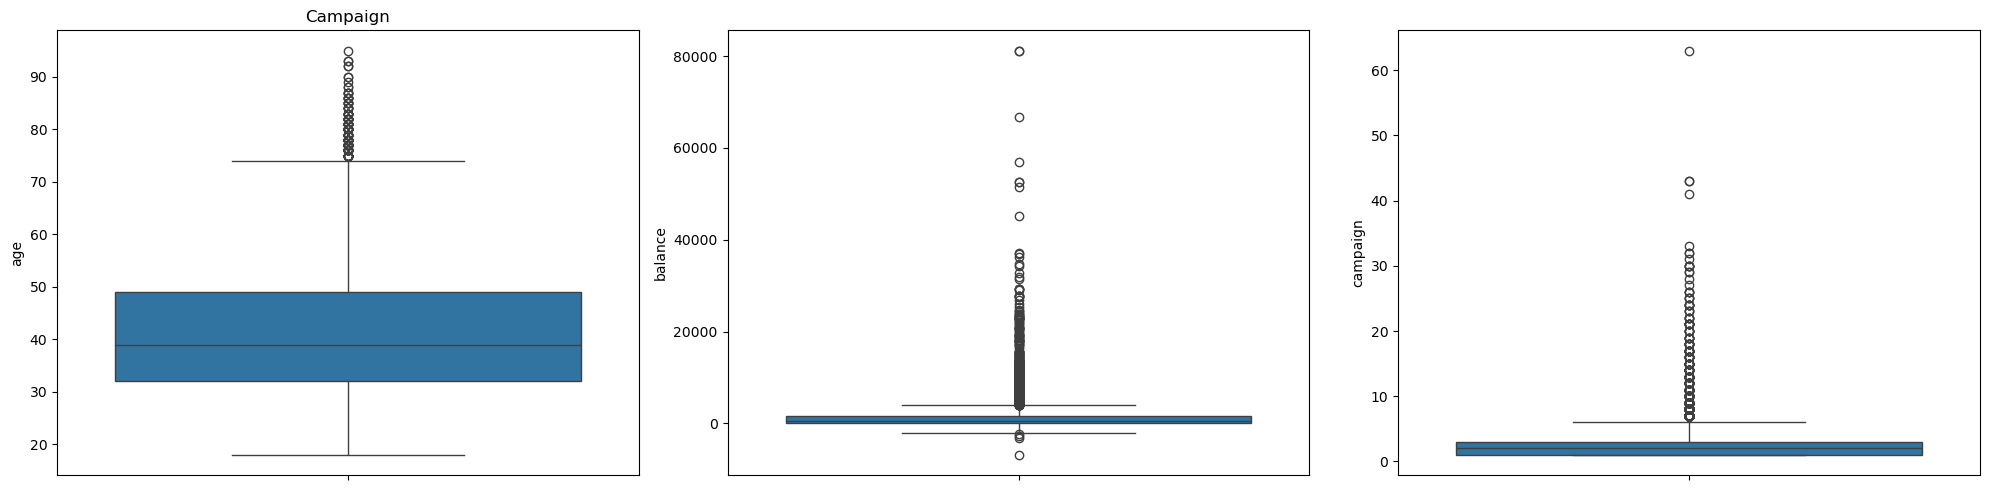

In [55]:
# 2.2 Handle Missing / Unknown Values
# Boxplots
import matplotlib.pyplot as plt 
import seaborn as sns
fig, axes = plt.subplots(1,3, figsize = (20,5))
sns.boxplot(y=df['age'], ax = axes[0])
axes[0].set_title("Age")
sns.boxplot(y=df['balance'], ax = axes[1])
axes[0].set_title("balance")
sns.boxplot(y=df['campaign'], ax = axes[2])
axes[0].set_title("Campaign")

plt.tight_layout()
plt.show


In [57]:
# IQR 

def detect_outliers_iqr(column):
    Q1 = column.quantile(0.35)
    Q3 = column.quantile(0.85)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

for col in ['age', 'balance', 'campaign']:
    lower, upper = detect_outliers_iqr(df[col])
    print(f"{col}: Lower={lower}, Upper={upper}")

age: Lower=2.5, Upper=86.5
balance: Lower=-3677.5, Upper=6822.5
campaign: Lower=-3.5, Upper=8.5


In [59]:
#Correct, cap, or remove outliers with explanation
for col in ['balance', 'campaign']:
    lower, upper = detect_outliers_iqr(df[col])
    df[col] = df[col].clip(lower, upper)

In [61]:
# 2.3 Data Type Fixing
df.dtypes


age            int64
job           object
marital       object
education     object
default       object
balance      float64
housing       object
loan          object
contact       object
day            int64
month         object
duration       int64
campaign     float64
pdays          int64
previous       int64
poutcome      object
deposit       object
dtype: object

In [63]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [65]:

binary_cols = ['deposit', 'housing', 'loan', 'default']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [69]:
df['deposit'].value_counts()

deposit
0    5873
1    5289
Name: count, dtype: int64

In [73]:

df.to_csv("bank/bank.csv", index = False)

In [79]:
# 2.4 Feature Engineering
import pandas as pd

df = pd.read_csv("bank/bank.csv")
df.head(10)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        11162 non-null  int64  
 1   job        11162 non-null  object 
 2   marital    11162 non-null  object 
 3   education  11162 non-null  object 
 4   default    11162 non-null  int64  
 5   balance    11162 non-null  float64
 6   housing    11162 non-null  int64  
 7   loan       11162 non-null  int64  
 8   contact    11162 non-null  object 
 9   day        11162 non-null  int64  
 10  month      11162 non-null  object 
 11  duration   11162 non-null  int64  
 12  campaign   11162 non-null  float64
 13  pdays      11162 non-null  int64  
 14  previous   11162 non-null  int64  
 15  poutcome   11162 non-null  object 
 16  deposit    11162 non-null  int64  
dtypes: float64(2), int64(9), object(6)
memory usage: 1.4+ MB


In [97]:
def age_group(age):
    if age >= 18 and age <= 30:
        return 'Young Adult'
    elif age>= 31 and age <= 45:
        return 'Adult'
        
    elif age>= 46 and age <= 60:
        return 'Middle-Aged'
    else:
        return 'Senior'

df['age_group'] = df['age'].apply(age_group)
df['age_group'] = df['age_group'].astype('category')



Different age groups have distinct financial behaviors:

Young adults are more likely to use digital banking and have lower balances.

Middle-aged customers often hold loans, mortgages, and savings products.

Seniors typically have stable deposits and lower credit risk.

Grouping age improves model interpretability and helps identify target customer segments for banking products.

Reduces sensitivity to outliers and avoids assuming a linear relationship between age and banking outcomes.

In [89]:
def balance_category(balance):
    if balance < 1500:
        return 'Low'
    elif balance <= :
        return 'Medium'
    else:
        return 'High'

df['balance_category'] = df['balance'].apply(balance_category)
df['balance_category'] = df['balance_category'].astype('category')

Account balance reflects a customer’s financial stability and creditworthiness.

Helps distinguish high-value customers from low-balance or at-risk customers.

Supports better predictions for:

Loan approval likelihood

Deposit product targeting

Customer churn or retention

Categorization reduces skewness in financial data, which is common in banking datasets.

In [91]:
def contact_intensity(campaign):
    if campaign <= 2:
        return 'Low'
    elif campaign <= 5:
        return 'Medium'
    else:
        return 'High'

df['contact_intensity'] = df['campaign'].apply(contact_intensity)
df['contact_intensity'] = df['contact_intensity'].astype('category')

Measures how frequently a customer is contacted by the bank (calls, emails, campaigns).

High contact intensity may indicate:

Strong marketing focus on a valuable customer, or

Customer dissatisfaction or hesitation.

Helps evaluate marketing effectiveness and avoid over-contacting customers, which can negatively impact satisfaction.

Enables better modeling of customer engagement and response probability.

In [102]:

print(df[['age_group','balance_category','contact_intensity']].head(10))

# Value counts
print(df['age_group'].value_counts())
print(df['balance_category'].value_counts())
print(df['contact_intensity'].value_counts())

     age_group balance_category contact_intensity
0  Middle-Aged           Medium               Low
1  Middle-Aged              Low               Low
2        Adult              Low               Low
3  Middle-Aged           Medium               Low
4  Middle-Aged              Low               Low
5        Adult              Low               Low
6  Middle-Aged              Low               Low
7  Middle-Aged              Low               Low
8        Adult              Low               Low
9  Young Adult           Medium            Medium
age_group
Adult          5522
Middle-Aged    3022
Young Adult    2007
Senior          611
Name: count, dtype: int64
balance_category
Low       8053
Medium    2545
High       564
Name: count, dtype: int64
contact_intensity
Low       7826
Medium    2470
High       866
Name: count, dtype: int64


In [104]:

df.to_csv("bank/bank.csv", index=False)

 # Exploratory Data Analysis

In [107]:
# 3.1 Univariate Analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("bank/bank.csv")

df.head(10)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                11162 non-null  int64  
 1   job                11162 non-null  object 
 2   marital            11162 non-null  object 
 3   education          11162 non-null  object 
 4   default            11162 non-null  int64  
 5   balance            11162 non-null  float64
 6   housing            11162 non-null  int64  
 7   loan               11162 non-null  int64  
 8   contact            11162 non-null  object 
 9   day                11162 non-null  int64  
 10  month              11162 non-null  object 
 11  duration           11162 non-null  int64  
 12  campaign           11162 non-null  float64
 13  pdays              11162 non-null  int64  
 14  previous           11162 non-null  int64  
 15  poutcome           11162 non-null  object 
 16  deposit            111

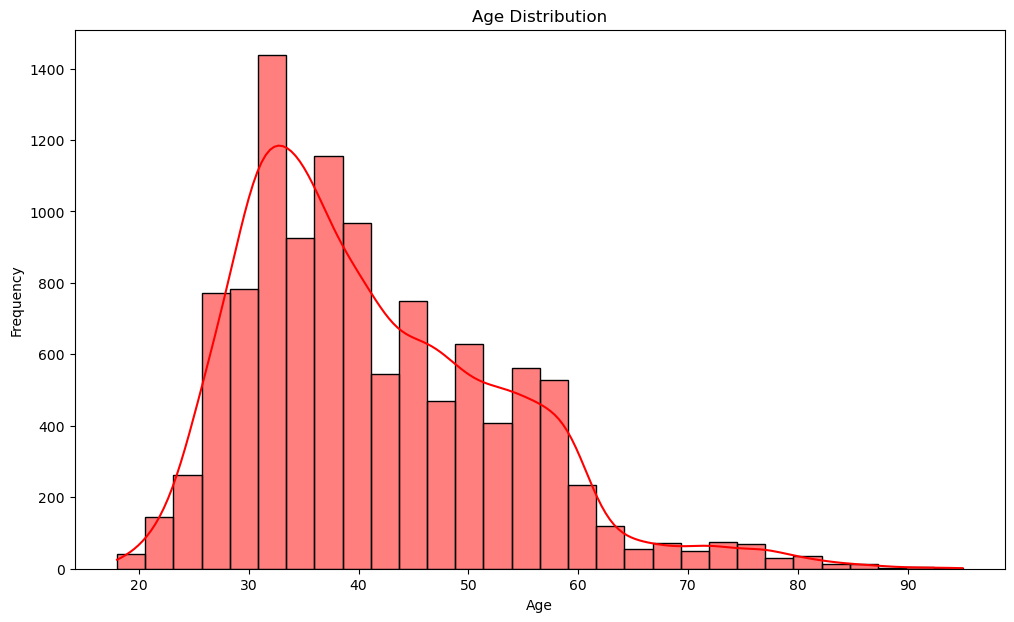

In [109]:
# Distribution of age

plt.figure(figsize=(12,7))
sns.histplot(df['age'], bins=30, kde=True, color='red')
plt.title('Age-Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

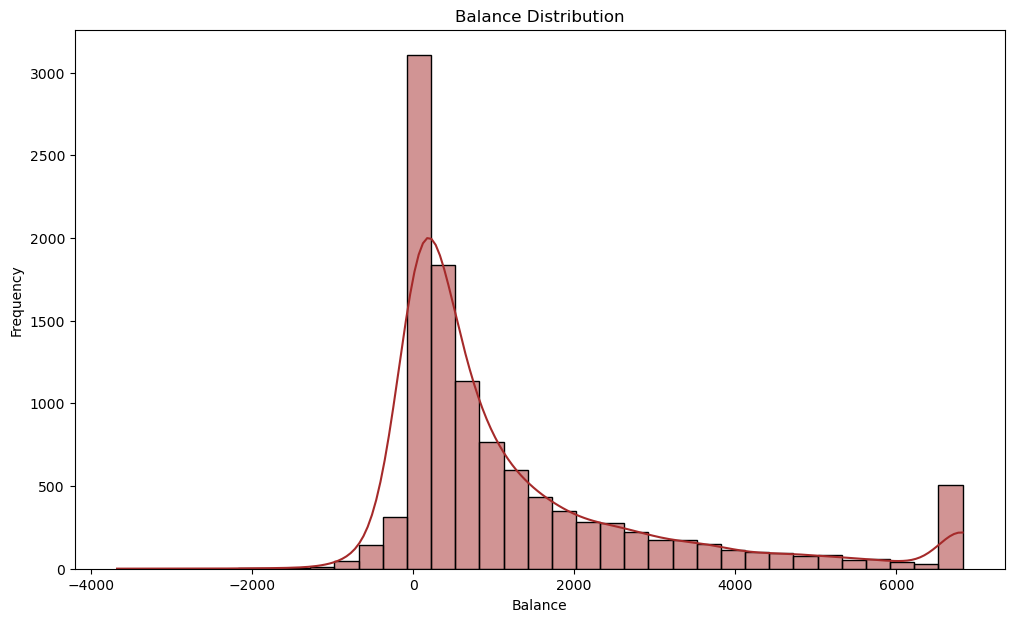

In [121]:
# Distribution of balance
plt.figure(figsize=(12,7))
sns.histplot(df['balance'], bins=35, kde=True, color='brown')
plt.title('Balance-Distribution')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.show()

C:\Users\KIIT\AppData\Local\Temp\ipykernel_8176\4124134582.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['job'], order=df['job'].value_counts().index, palette='cubehelix')


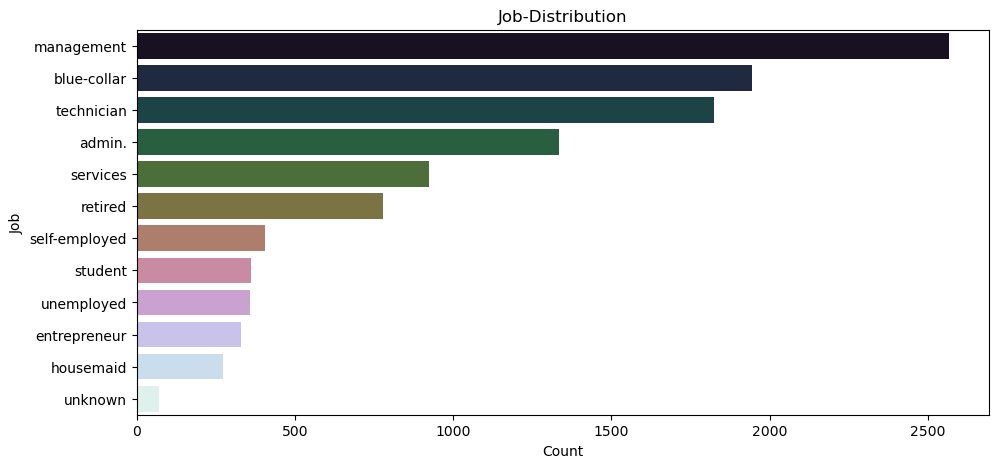

In [125]:
#Countplot of job
plt.figure(figsize=(11,5))
sns.countplot(y=df['job'], order=df['job'].value_counts().index, palette='cubehelix')
plt.title('Job-Distribution')
plt.xlabel('Count')
plt.ylabel('Job')
plt.show()

C:\Users\KIIT\AppData\Local\Temp\ipykernel_8176\3086906721.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['deposit'], palette='viridis')


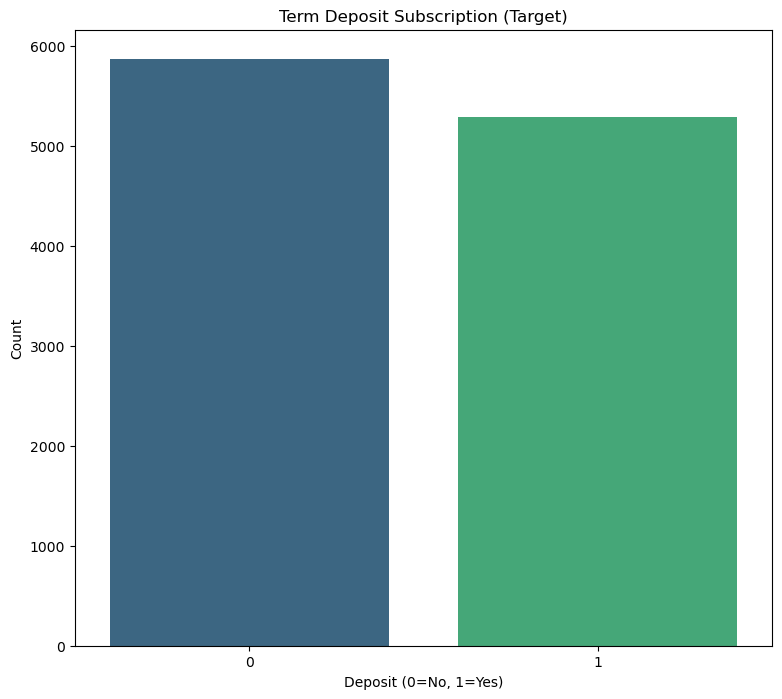

In [129]:
# Countplot of target variable (y)
plt.figure(figsize=(9,8))
sns.countplot(x=df['deposit'], palette='viridis')
plt.title('Term Deposit Subscription (Target)')
plt.xlabel('Deposit (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

C:\Users\KIIT\AppData\Local\Temp\ipykernel_8176\1894277223.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='deposit', y='balance', data=df, palette='Set3')


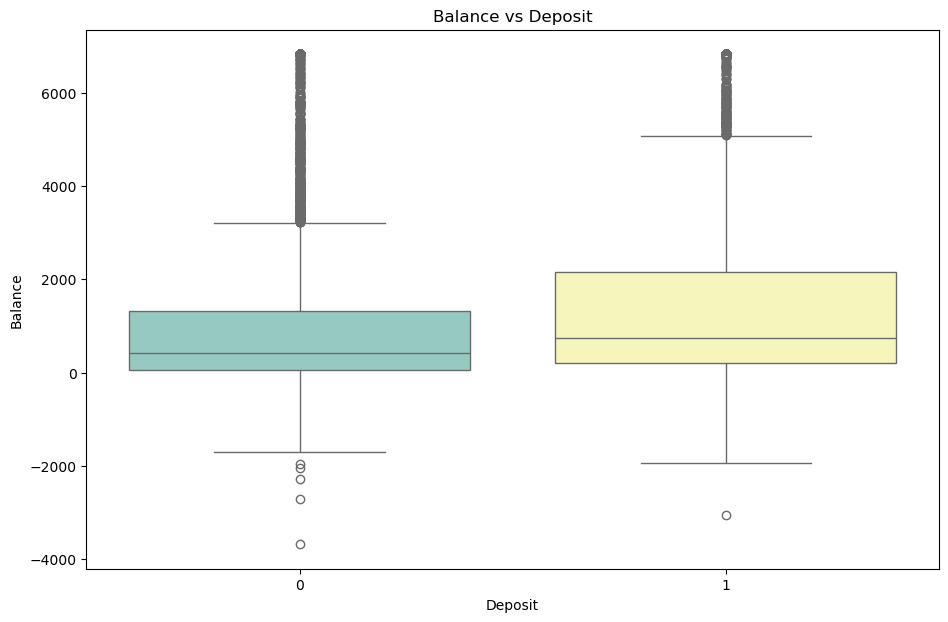

In [131]:
# 3.2 Bivariate Analysis
#1. Does balance affect term deposit subscription?

plt.figure(figsize=(11,7))
sns.boxplot(x='deposit', y='balance', data=df, palette='Set3')
plt.title('Balance vs Deposit')
plt.xlabel('Deposit')
plt.ylabel('Balance')
plt.show()

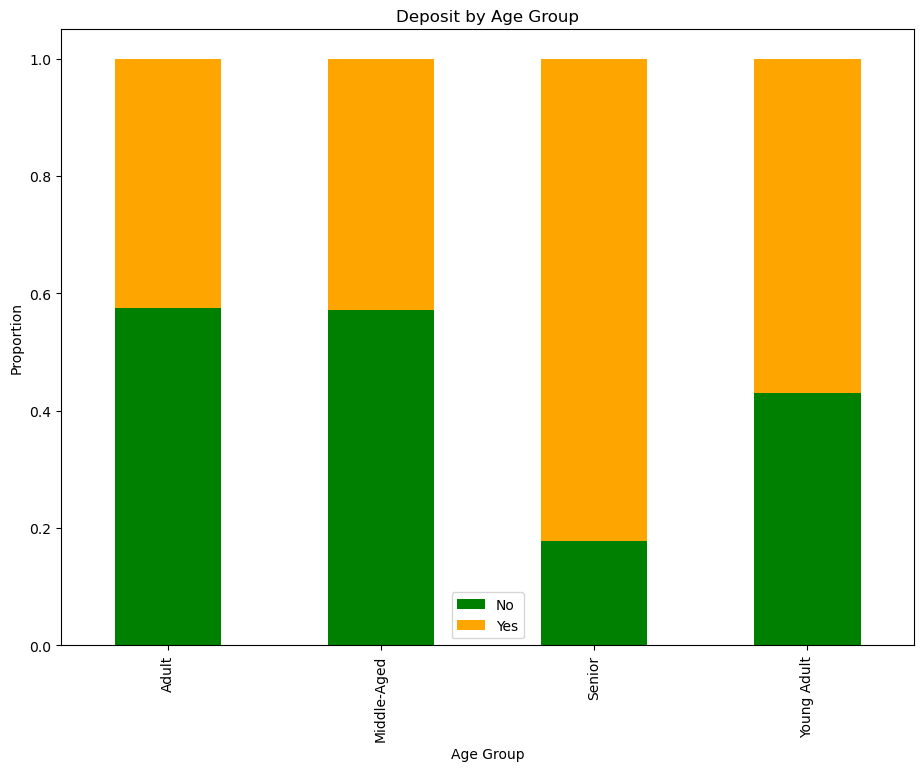

In [133]:
# 2) Is there a relationship between age group and subscription?
age_deposit = pd.crosstab(df['age_group'], df['deposit'], normalize='index')

age_deposit.plot(kind='bar', stacked=True, figsize=(11,8), color=['green','orange'])
plt.title('Deposit by Age Group')
plt.ylabel('Proportion')
plt.xlabel('Age Group')
plt.legend(['No','Yes'])
plt.show()

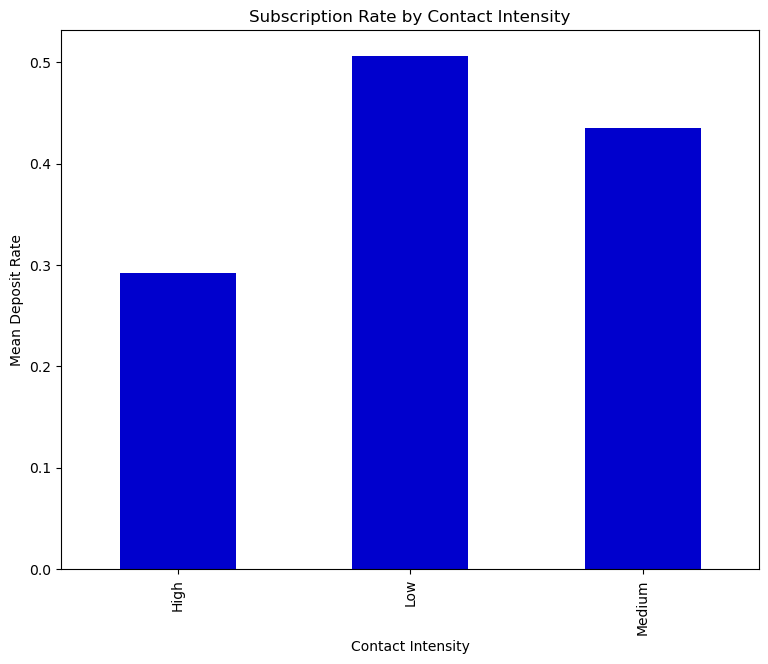

In [141]:
# 3. Does the number of contacts (campaign) affect success rate?
campaign_success = df.groupby('contact_intensity')['deposit'].mean()
campaign_success.plot(kind='bar', figsize=(9,7), color='mediumblue')
plt.title('Subscription Rate by Contact Intensity')
plt.ylabel('Mean Deposit Rate')
plt.xlabel('Contact Intensity')
plt.show()

Object `frequently` not found.


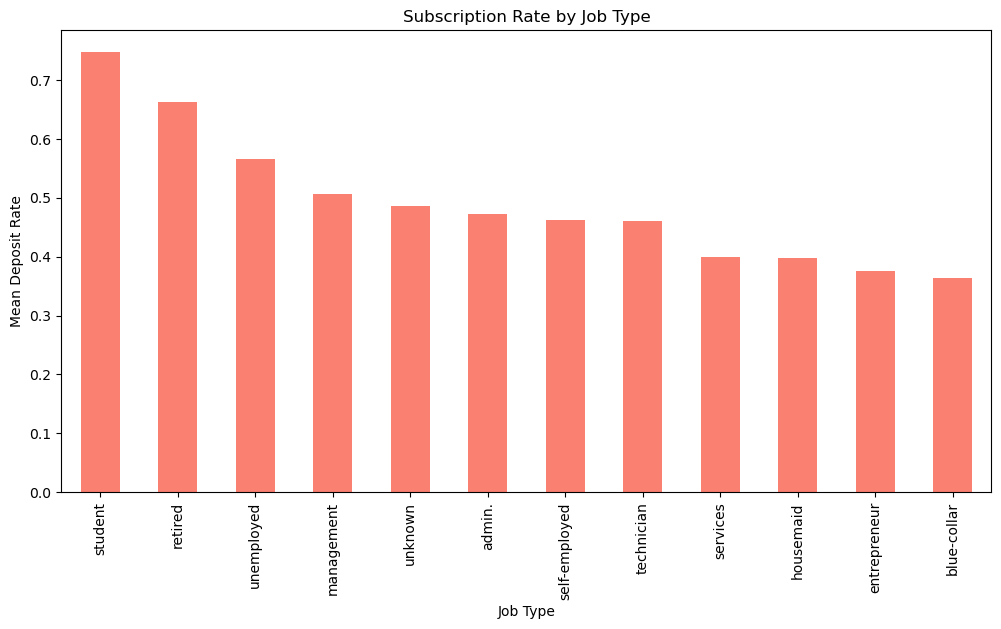

In [143]:
# 4. Which job types subscribe more frequently?
job_deposit = df.groupby('job')['deposit'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
job_deposit.plot(kind='bar', color='salmon')
plt.title('Subscription Rate by Job Type')
plt.ylabel('Mean Deposit Rate')
plt.xlabel('Job Type')
plt.show()

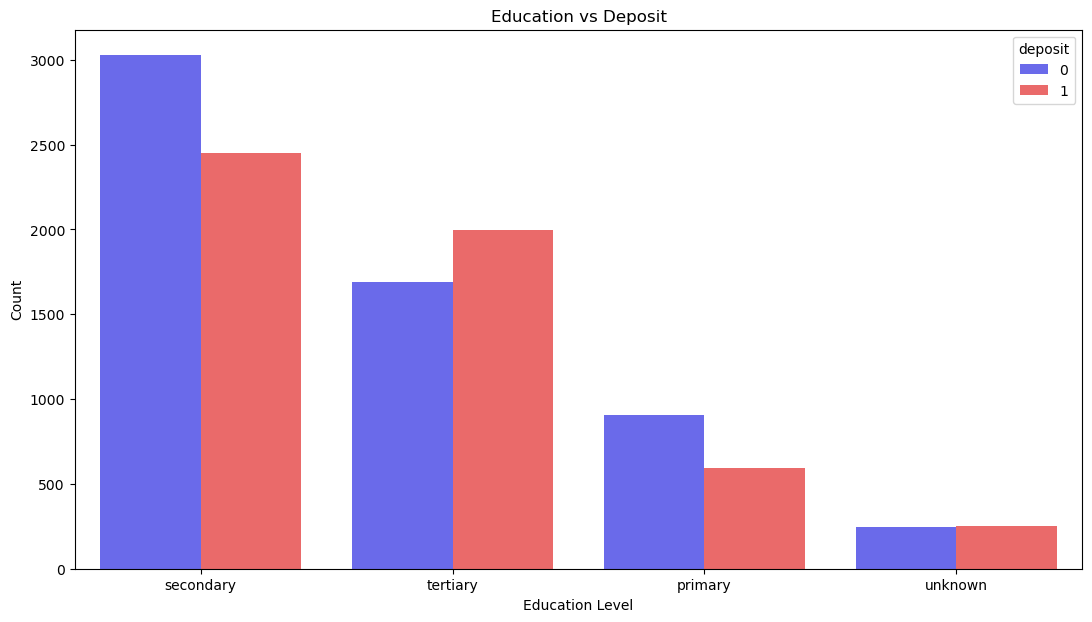

In [145]:
# 5 Does education level influence subscription?

plt.figure(figsize=(13,7))
sns.countplot(x='education', hue='deposit', data=df, palette='seismic')
plt.title('Education vs Deposit')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.show()

3.3 Insight Summary

1)Age Influence on Subscription
Middle-aged and senior customers subscribe to term deposits more frequently than younger customers, indicating higher financial stability and long-term savings goals.

2)Balance and Subscription Relationship
Customers with higher account balances show a significantly higher subscription rate, confirming balance as a strong indicator of conversion potential.

3)Effect of Contact Frequency
Moderate campaign contacts result in higher success rates, while excessive contacts reduce subscriptions, suggesting customer fatigue from over-marketing.

4)Job Type Conversion Patterns
Customers in management, administrative, and retired job roles subscribe more often compared to blue-collar workers and students, reflecting income stability and lower risk.

5)Role of Education Level
Customers with secondary and tertiary education levels have higher subscription rates, likely due to better financial awareness and understanding of term deposit benefits.

# Machine Learning Modeling

In [150]:
import pandas as pd
import numpy as np

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("bank/bank.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,age_group,balance_category,contact_intensity
0,59,admin.,married,secondary,0,2343.0,1,0,unknown,5,may,1042,1.0,-1,0,unknown,1,Middle-Aged,Medium,Low
1,56,admin.,married,secondary,0,45.0,0,0,unknown,5,may,1467,1.0,-1,0,unknown,1,Middle-Aged,Low,Low
2,41,technician,married,secondary,0,1270.0,1,0,unknown,5,may,1389,1.0,-1,0,unknown,1,Adult,Low,Low
3,55,services,married,secondary,0,2476.0,1,0,unknown,5,may,579,1.0,-1,0,unknown,1,Middle-Aged,Medium,Low
4,54,admin.,married,tertiary,0,184.0,0,0,unknown,5,may,673,2.0,-1,0,unknown,1,Middle-Aged,Low,Low


In [152]:
X = df.drop(columns=['deposit'])
y = df['deposit']

In [154]:

categorical_cols = X.select_dtypes(include='object').columns

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [156]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [158]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [160]:

lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [162]:
dt = DecisionTreeClassifier(random_state=56)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [164]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [166]:
accuracy = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'Decision Tree': accuracy_score(y_test, y_pred_dt),
    'Random Forest': accuracy_score(y_test, y_pred_rf)
}
accuracy

{'Logistic Regression': 0.8320644872369011,
 'Decision Tree': 0.799820868786386,
 'Random Forest': 0.8589341692789969}

Logistic Regression Confusion Matrix:
 [[1003  172]
 [ 203  855]] 



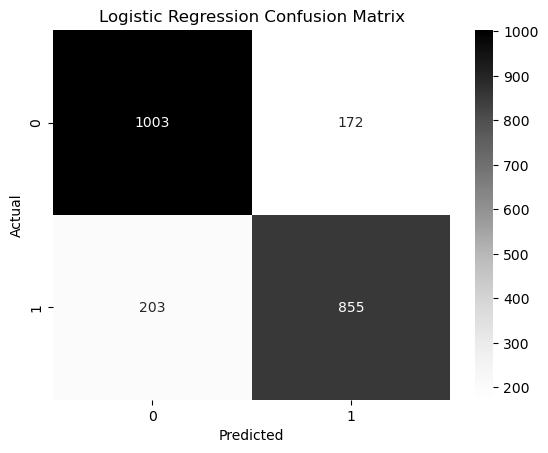

Decision Tree Confusion Matrix:
 [[962 213]
 [234 824]] 



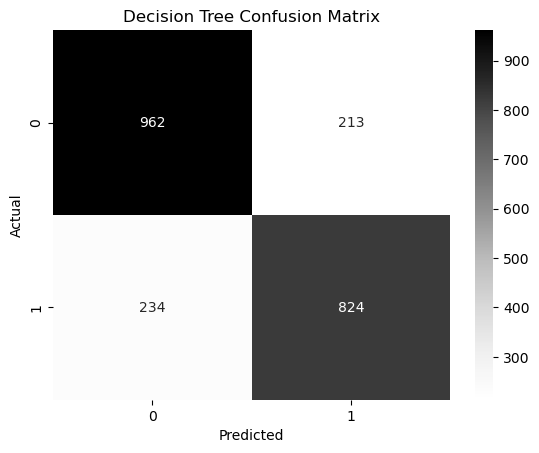

Random Forest Confusion Matrix:
 [[979 196]
 [119 939]] 



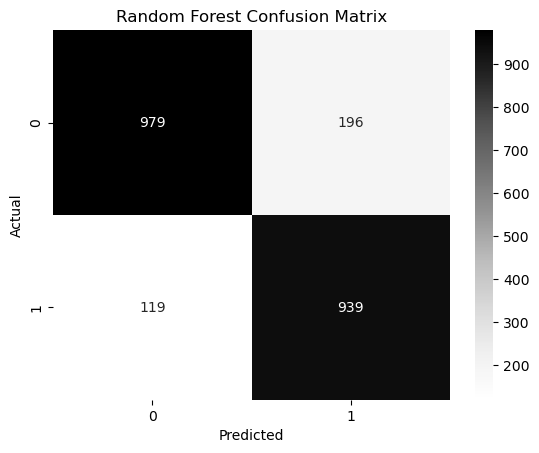

In [178]:
models_preds = {'Logistic Regression': y_pred_lr,
                'Decision Tree': y_pred_dt,
                'Random Forest': y_pred_rf}

for model, y_pred in models_preds.items():
    cm = confusion_matrix(y_test, y_pred)
    print(f"{model} Confusion Matrix:\n", cm, "\n")
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greys')
    plt.title(f'{model} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [180]:

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr),
                 accuracy_score(y_test, y_pred_dt),
                 accuracy_score(y_test, y_pred_rf)]
})
comparison

,Model,Accuracy
0,Logistic Regression,0.832064
1,Decision Tree,0.799821
2,Random Forest,0.858934


In [182]:
test_results = pd.DataFrame({
    'Actual': y_test[:20].values,
    'Predicted': y_pred_rf[:20]
})
test_results

,Actual,Predicted
0,0,1
1,1,1
2,0,0
3,0,0
4,1,1
5,0,0
6,0,0
7,1,0
8,1,1
9,1,1


In [194]:

# Sample customer profile
sample = {
    "age": 42,
    "job": "management",
    "marital": "married",
    "education": "tertiary",
    "balance": 6000,
    "housing": "yes",
    "loan": "no",
    "contact": "cellular",
    "campaign": 2,
    "poutcome": "success"
}

# Convert to DataFrame
sample_df = pd.DataFrame([sample])

# Apply feature engineering
sample_df['age_group'] = sample_df['age'].apply(lambda x: 'Young Adult' if x<=30 else ('Adult' if x<=45 else ('Middle-Aged' if x<=60 else 'Senior')))
sample_df['balance_category'] = sample_df['balance'].apply(lambda x: 'Low' if x<1000 else ('Medium' if x<=5000 else 'High'))
sample_df['contact_intensity'] = sample_df['campaign'].apply(lambda x: 'Low' if x<=2 else ('Medium' if x<=5 else 'High'))

# Drop raw columns if needed and encode categorical features
sample_df_encoded = pd.get_dummies(sample_df, columns=['job','marital','education','housing','loan','contact','poutcome','age_group','balance_category','contact_intensity'], drop_first=True)

# Align columns with training data
sample_df_encoded = sample_df_encoded.reindex(columns=X_train.columns, fill_value=0)

# Scale features
sample_scaled = scaler.transform(sample_df_encoded)

# Predict
prediction = rf.predict(sample_scaled)[0]
prediction_prob = rf.predict_proba(sample_scaled)[0][1]

print(f"Predicted Deposit: {prediction} (1=Yes, 0=No)")
print(f"Probability of subscription: {prediction_prob:.2f}")

Predicted Deposit: 0 (1=Yes, 0=No)
Probability of subscription: 0.30


C:\Users\KIIT\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\KIIT\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [198]:
import os 
os.getcwd()

'C:\\Users\\KIIT'

In [200]:
os.makedirs("models", exist_ok=True)
joblib.dump(X_train.columns, "models/X_train_columns.pkl")


['models/X_train_columns.pkl']

In [202]:
model_path = os.path.join(os.getcwd(), "models")
os.makedirs(model_path, exist_ok=True)

joblib.dump(X_train.columns, os.path.join(model_path, "X_train_columns.pkl"))


['C:\\Users\\KIIT\\models\\X_train_columns.pkl']

In [204]:
import os
print("Working directory:", os.getcwd())
print("Can write here?", os.access(os.getcwd(), os.W_OK))


Working directory: C:\Users\KIIT
Can write here? True


In [210]:

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_res).value_counts())

Before SMOTE: deposit
0    4698
1    4231
Name: count, dtype: int64
After SMOTE: deposit
0    4698
1    4698
Name: count, dtype: int64


In [215]:
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 5-fold cross-validation
cv_scores = cross_val_score(rf, X_train_res, y_train_res, cv=5, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())


Cross-validation scores: [0.85744681 0.84672698 0.85151676 0.84513039 0.86695051]
Mean CV accuracy: 0.8535542898554007


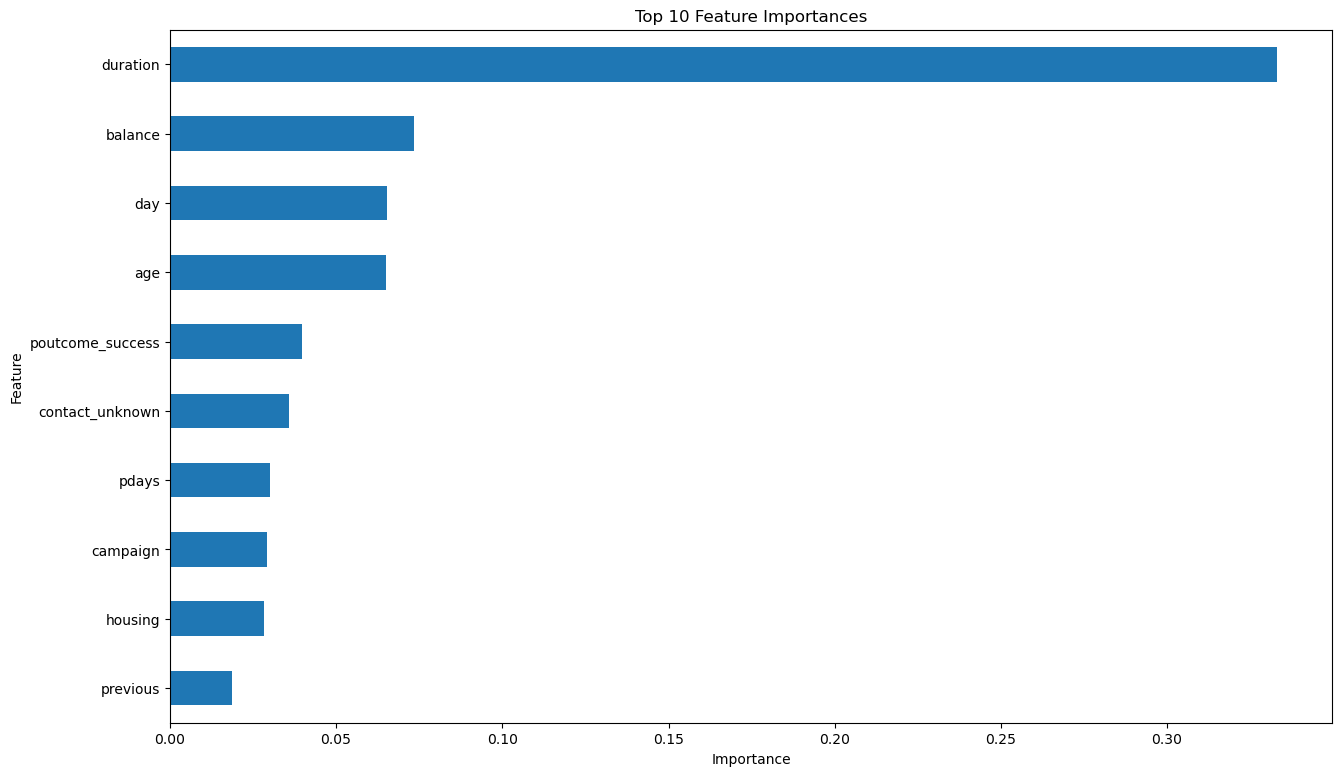

In [221]:
import matplotlib.pyplot as plt


rf.fit(X_train_res, y_train_res)


importances = rf.feature_importances_
features = X_train.columns
feat_importance = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(15,9))
feat_importance.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()